# 6.2 Neural Network with Julia

As was seen in the previous notebook, a Neural Network can get very big and very complex to define with lots of parameters.

In Julia, there are libraries that can take care of all the Neural Network definitions and setup.  Here we will use the `Lux.jl` library in Julia to define, setup and tune the Neural Network 

In [2]:
using Zygote
using Lux
using Random
using Distributions
using CairoMakie
using Optimisers
using Optimization
using OptimizationOptimisers
using ComponentArrays

In this notebook, we will see how we can use the `Lux()` package in Julia to set up and use Neural Networks. 
Let's initially define a simple Neural Network in Lux

$NN(x)=Wx+b$

with one input,$x$ and one output, $NN(x)$ with weight and bias $W$ and $b$

In [3]:
model01 = Chain(Dense(1 => 1))

Chain(
    layer_1 = Dense(1 => 1),                      # 2 parameters
)         # Total: 2 parameters,
          #        plus 0 states.

In general, you are usually encouraged to use random number generator to initialize the values of the weight and bias. 

In [4]:
# Initialize the model weights and state
rng = Random.default_rng()
parameters, layer_states = Lux.setup(rng, model01)

((layer_1 = (weight = Float32[0.6798217;;], bias = Float32[0.9002472]),), (layer_1 = NamedTuple(),))

If you want to, you can explicitly change the value of $W$ to 2.0 and $b$ to 1.0 using the code below

In [5]:
parameters.layer_1.weight.=Float32(2.0)
parameters.layer_1.bias.=Float32(1.0)

1-element Vector{Float32}:
 1.0

Note that by default, the Neural Network is defined as single precision Float32 type.  This is because single precision is accepted to be the optimal balance between precision for accurate training and computational speed/memory efficiency on GPUs.

Let's plot a graph of the Neural Network to see how it looks like

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Matrix{Float32}] x B [LinearAlgebra.Adjoint{Float64, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl /Users/asho/.julia/packages/LuxLib/zPBrt/src/impl/matmul.jl:194


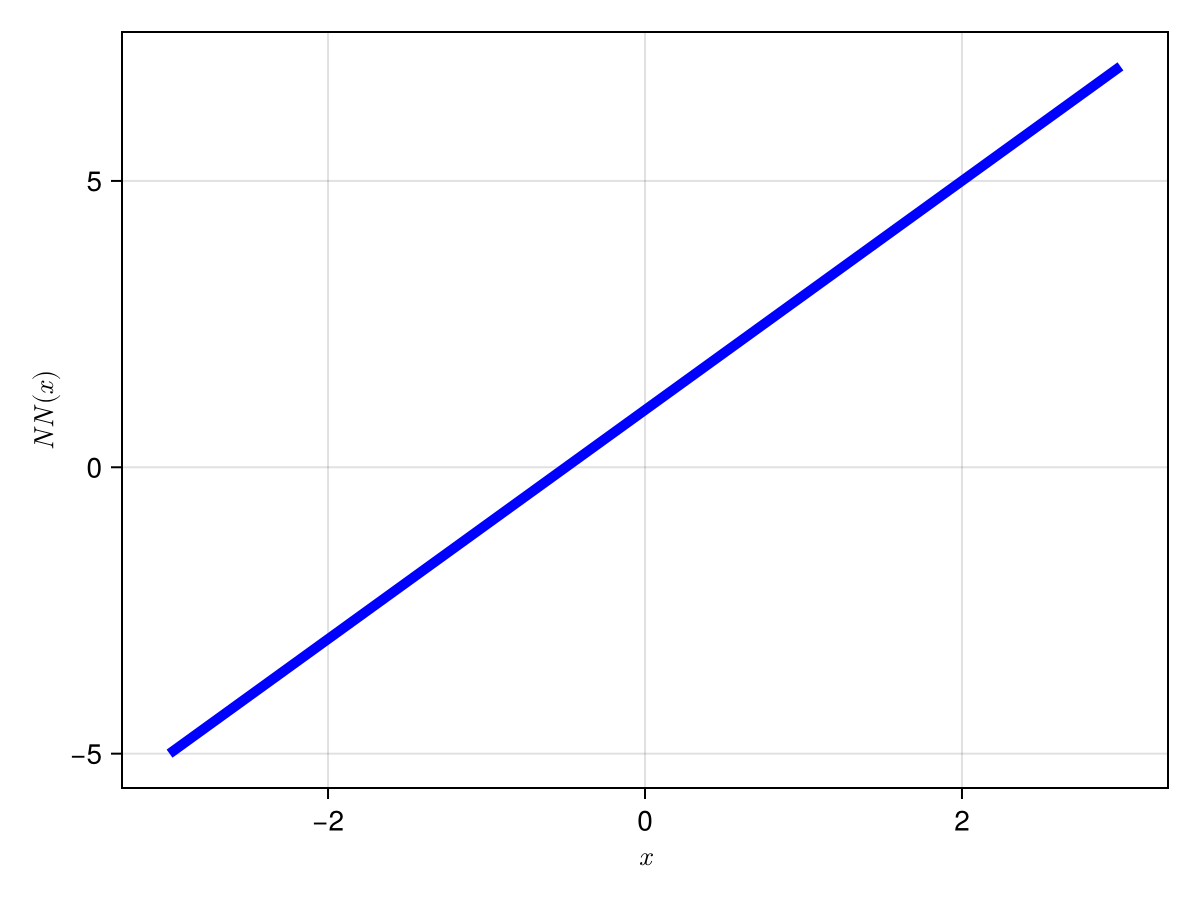

In [6]:
xgrid=-3.0:0.01:3.0
y_prediction,_=model01(xgrid',parameters, layer_states)
fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"NN(x)")
lines!(ax,xgrid,y_prediction[:];color=:blue,label="prediction",linewidth=5)
save("../figures/06p02NeuraNetworkWithJulia01.svg",fig)
fig

---

**Class Demo 01:** Define and plot the Neural Network $NN(x)=\sin(3x+4)$ for $x\in[-2,3]$

---

Let's now generate some data and try to train this Neural Network so that it fits the data.  We will artificially generate some data with the function $y(x)=x+3$.  Let's see our current Neural Network prediction with this data

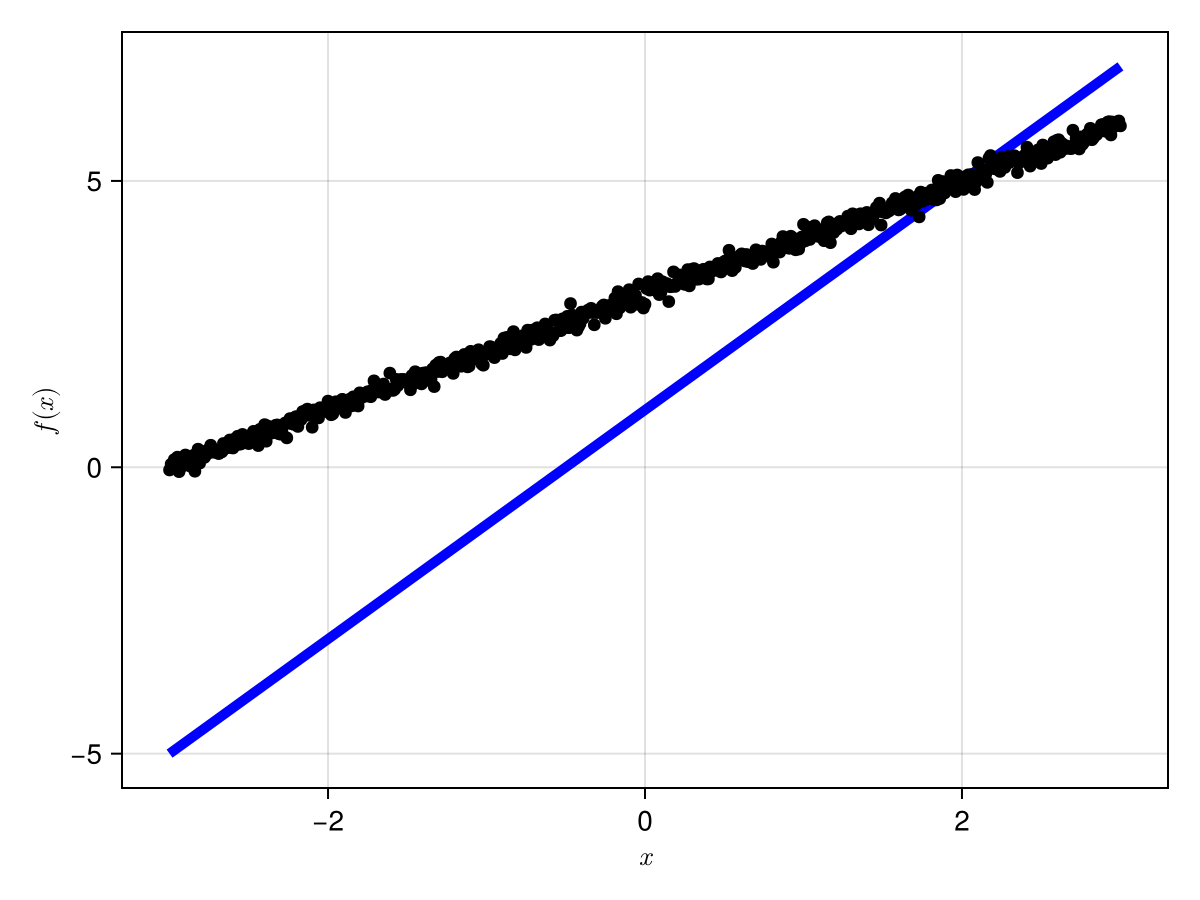

In [7]:
xgrid=collect(-3.0:0.01:3.0) 
N_SAMPLES=length(xgrid)

#y_prediction,_=model01(reshape(xgrid,(1,N_SAMPLES)),parameters, layer_states)
y_prediction,_=model01(xgrid',parameters, layer_states)
y_data=xgrid.+3+0.1*randn(N_SAMPLES)

fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)")
lines!(ax,xgrid,y_prediction[:];color=:blue,label="prediction",linewidth=5)
scatter!(ax,xgrid,y_data[:];color=:black,label="data")
fig

Now we try to train this Neural Network. As usual, first define  the loss function

In [8]:
# loss function
function loss_fn(p, ls)
    y_prediction, _= model01(xgrid', p, ls)
    loss = 0.5 * mean((y_prediction[:] .- y_data).^2)
    return loss
end

loss_fn (generic function with 1 method)

In [9]:
f_loss=(ps) -> loss_fn(ps,layer_states)

#15 (generic function with 1 method)

We can use `Zygote()` to find the gradient of the loss function

In [10]:
Zygote.gradient(f_loss,parameters)[1]

(layer_1 = (weight = Float32[3.0189338;;], bias = Float32[-2.0037873]),)

Now we have the gradient, we can use standard gradient descent to train the neural network so that it best fits the data

In [11]:
α=0.01

new_weight=parameters.layer_1.weight[1]
new_bias=parameters.layer_1.bias[1]

for i=1:5000
    grads=Zygote.gradient(f_loss,parameters)[1]
    new_weight-=α*grads.layer_1.weight[1]
    new_bias-=α*grads.layer_1.bias[1]

    parameters.layer_1.weight.=Float32(new_weight)
    parameters.layer_1.bias.=Float32(new_bias)
end

Plot and compare

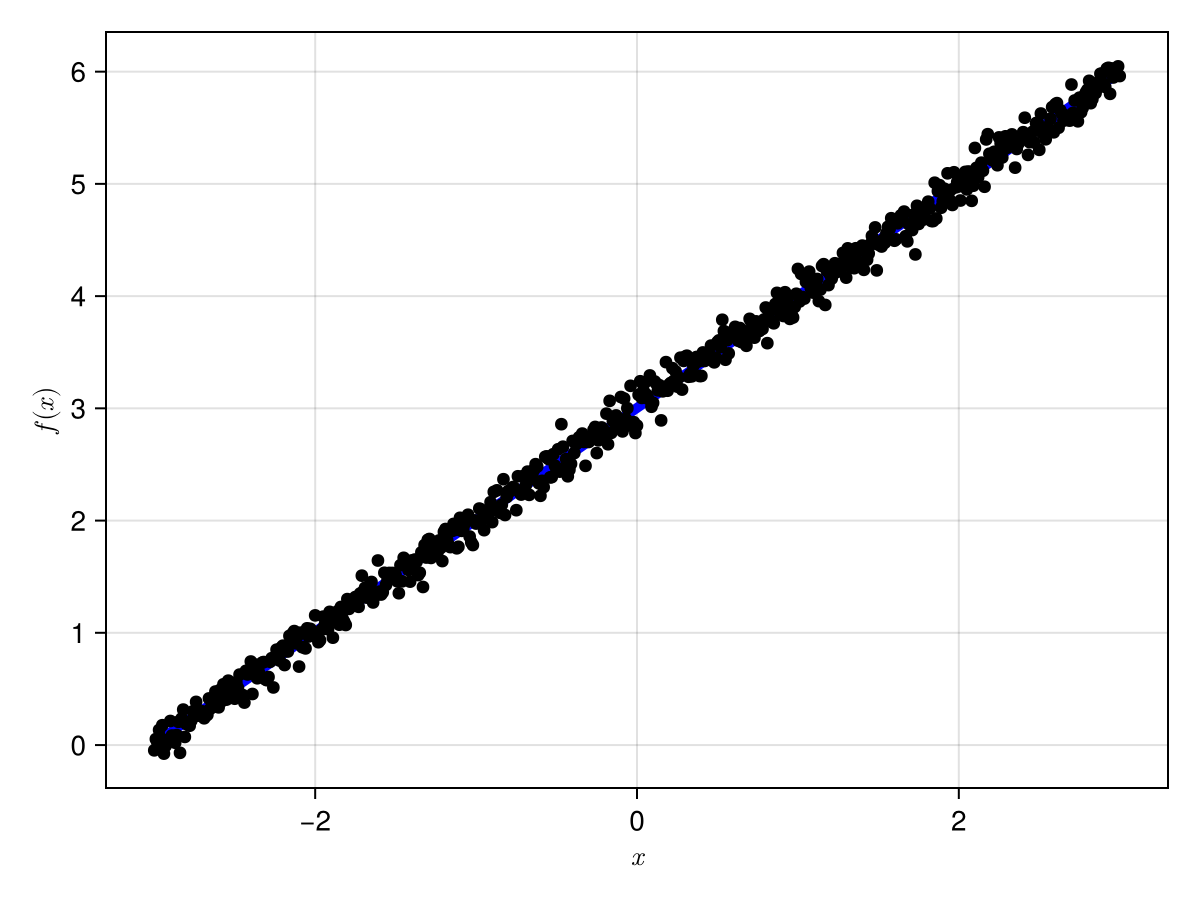

In [12]:
y_prediction,_=model01(xgrid',parameters, layer_states)


fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)")
lines!(ax,xgrid[:],y_prediction[:];color=:blue,label="prediction",linewidth=5)
scatter!(ax,xgrid[:],y_data[:];color=:black,label="data")
fig

In [13]:
parameters.layer_1.bias[1]

3.0037873f0

In [14]:
parameters.layer_1.weight[1]

0.997032f0

As you can see, the values of the weights and biases of the parameters are as expected

---

We can also introduce activation layers to make the Neural Network more complex and can better approximate nonlinear functions. The code below defines a neural network with a $\tanh()$ activation layer.  The Neural Network defined below looks like

$NN(x)=\tanh(Wx+b)$

It has one input and one output.

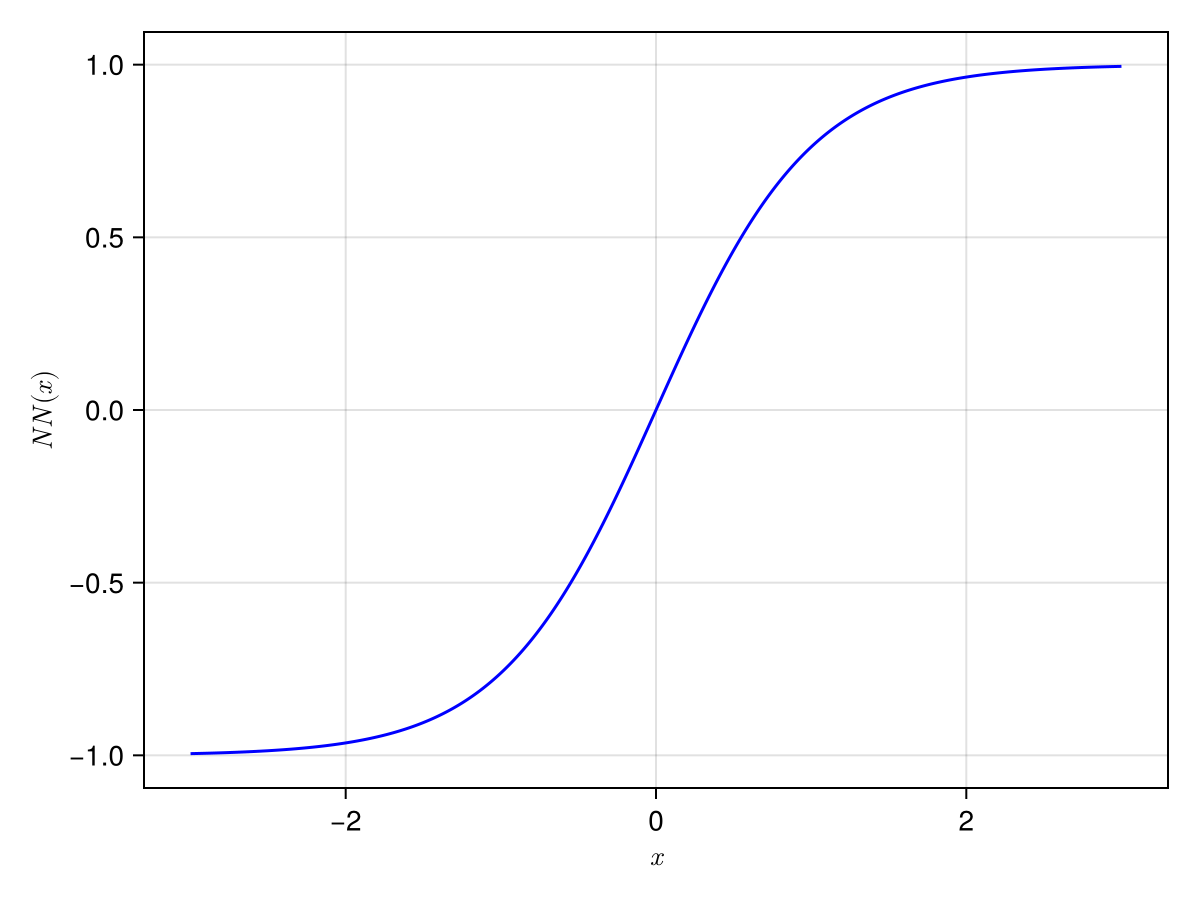

In [15]:
model02 = Chain(Dense(1 => 1,tanh))
parameters.layer_1.weight.=Float32(1.0) # Change the weight to 1.0
parameters.layer_1.bias.=Float32(0.0) # Change the bias to 0.0

y_prediction,_=model02(xgrid',parameters, layer_states) # predict the output of the Neural network

fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"NN(x)")
lines!(ax,xgrid[:],y_prediction[:];color=:blue,label="prediction")
fig

---

We will now define a Neural Network with one input layer, one output and one hidden layer.  There is we will use a $\tanh()$ activation function between the input and hidden layer.  Visually, the Neural Network looks like

![Alt text for screen readers](../figures/03p04Fig01.svg)

From the previous notebook, we have established that this Neural Network can be mathematically expressed as

$NN(x)=W_2\tanh(W_1x+b_1)+b_2$

In [16]:
model03 = Chain(Dense(1 => 1,tanh),
Dense(1=>1))

Chain(
    layer_1 = Dense(1 => 1, tanh),                # 2 parameters
    layer_2 = Dense(1 => 1),                      # 2 parameters
)         # Total: 4 parameters,
          #        plus 0 states.

Randomly initialise the weights and biases of the Neural network

In [17]:
# Initialize the model weights and state
parameters03, layer_states03 = Lux.setup(rng, model03)

((layer_1 = (weight = Float32[1.4448158;;], bias = Float32[-0.10772669]), layer_2 = (weight = Float32[-0.3272207;;], bias = Float32[-0.70124984])), (layer_1 = NamedTuple(), layer_2 = NamedTuple()))

You do not need to do this but you can set the weights and biases to be  $W_1=1$,$W_2=1$,$b_1=0$ and $b_2=0$.

In [18]:
parameters03.layer_1.weight.=Float32(1.0)
parameters03.layer_2.weight.=Float32(1.0)
parameters03.layer_1.bias.=Float32(0.0)
parameters03.layer_2.bias.=Float32(0.0)

1-element Vector{Float32}:
 0.0

Let's generate some data and try to fit this Neural Network to the data

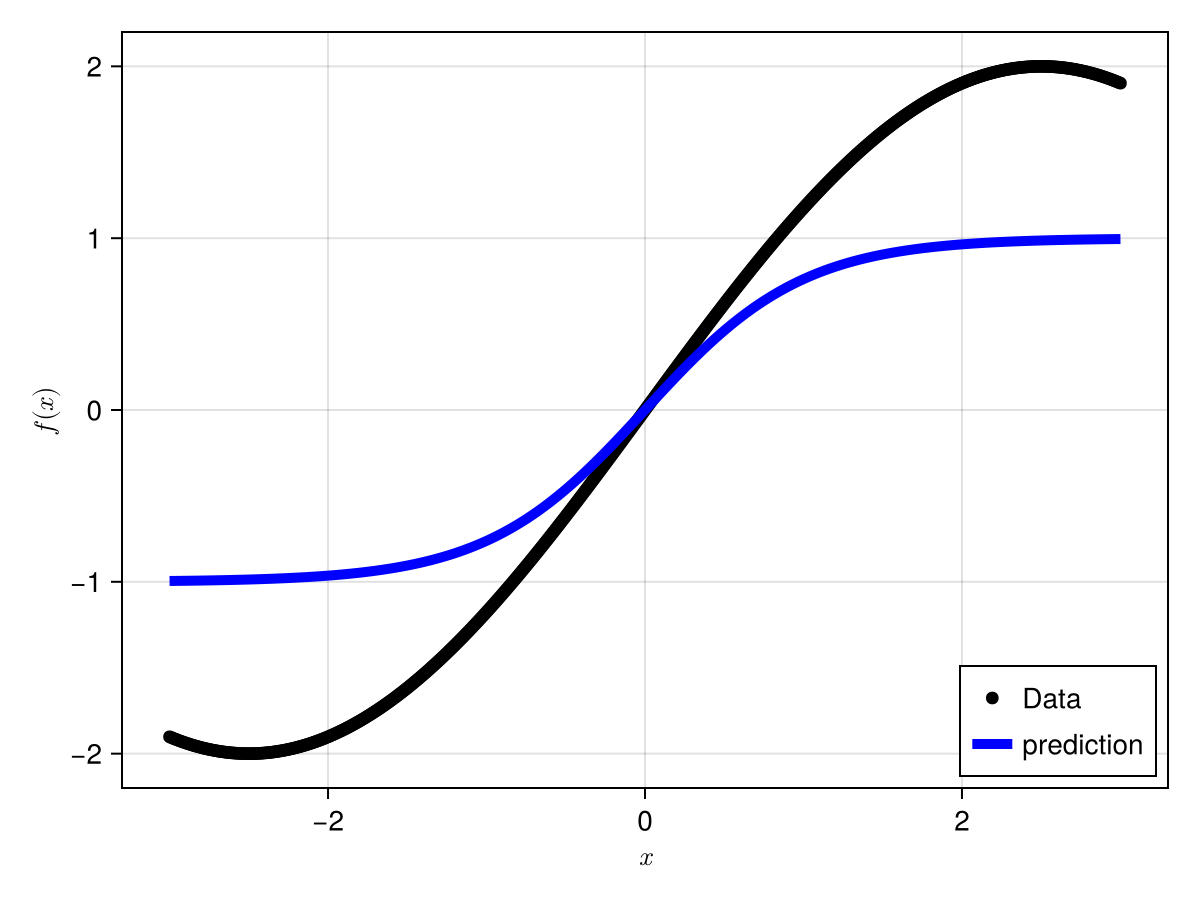

In [19]:
g(x)=2.0sin(pi *x/5 )
data03=g.(xgrid)


y_prediction,_=model03(xgrid',parameters03, layer_states03) # predict the output of the Neural network


fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)")
scatter!(ax,xgrid,data03;color=:black,label="Data")
lines!(ax,xgrid,y_prediction[:];linewidth=5,color=:blue,label="prediction")

axislegend(ax,  position = :rb,orientation = :vertical)

fig

We will now define the loss function

In [ ]:
# The loss function
function loss_fn03(p, ls)
    y_prediction, _= model03(xgrid', p, ls)
    loss = 0.5 * mean((y_prediction[:] .- data03).^2)
    return loss
end

loss_fn03 (generic function with 1 method)

In [21]:
f03_loss=(ps) -> loss_fn03(ps,layer_states03)[1]

#17 (generic function with 1 method)

In [22]:
f03_loss(parameters03)

0.25464908237964395

We can use  the `Zygote()` package to find calculate the gradient of the loss function

In [23]:
grads=Zygote.gradient(f03_loss,parameters03)[1]

(layer_1 = (weight = Float32[-0.10721234;;], bias = Float32[-2.3264607f-17]), layer_2 = (weight = Float32[-0.56792516;;], bias = Float32[-3.1658703f-17]))

Since we know how to calculate the gradient, we can use standard gradient descent to find the line of best fit

In [24]:
new_weight_l1=parameters03.layer_1.weight[1]
new_bias_l1=parameters03.layer_1.bias[1]
new_weight_l2=parameters03.layer_2.weight[1]
new_bias_l2=parameters03.layer_2.bias[1]

α=0.2

for i=1:500
    grads=Zygote.gradient(f03_loss,parameters03)[1]
    new_weight_l1-=α*grads.layer_1.weight[1]
    new_bias_l1-=α*grads.layer_1.bias[1]
    new_weight_l2-=α*grads.layer_2.weight[1]
    new_bias_l2-=α*grads.layer_2.bias[1]

    parameters03.layer_1.weight.=Float32(new_weight_l1)
    parameters03.layer_1.bias.=Float32(new_bias_l1)
    parameters03.layer_2.weight.=Float32(new_weight_l2)
    parameters03.layer_2.bias.=Float32(new_bias_l2)

    println(f03_loss(parameters03))
end

0.19241417605960304
0.14620459136559114
0.11214481123268719
0.08717325297509951
0.06892620422522926
0.05561128229294306
0.045888798363561835
0.03876824345121391
0.03352384122314505
0.029627426975085847
0.026696825395886293
0.024456793898072586
0.02270993856445393
0.02131513806748626
0.02017185505097349
0.019208685155886623
0.018375052616525007
0.017635249060930593
0.016964175803340593
0.01634423196189717
0.015763141573507854
0.015212401044487305
0.014686136263476552
0.014180344449122403
0.013692309791279651
0.013220209534452524
0.012762848993512741
0.012319433803634136
0.011889460805531276
0.011472589767450308
0.011068610204517533
0.010677365178150518
0.010298725577200567
0.009932581413938865
0.009578810193236318
0.00923728069546794
0.008907837196029217
0.008590310813068934
0.008284507655203088
0.007990208561996646
0.007707179318916679
0.00743516316762422
0.0071738929495430885
0.006923084965599306
0.006682445817382202
0.006451670788789293
0.006230450111664911
0.006018472488571302
0.005

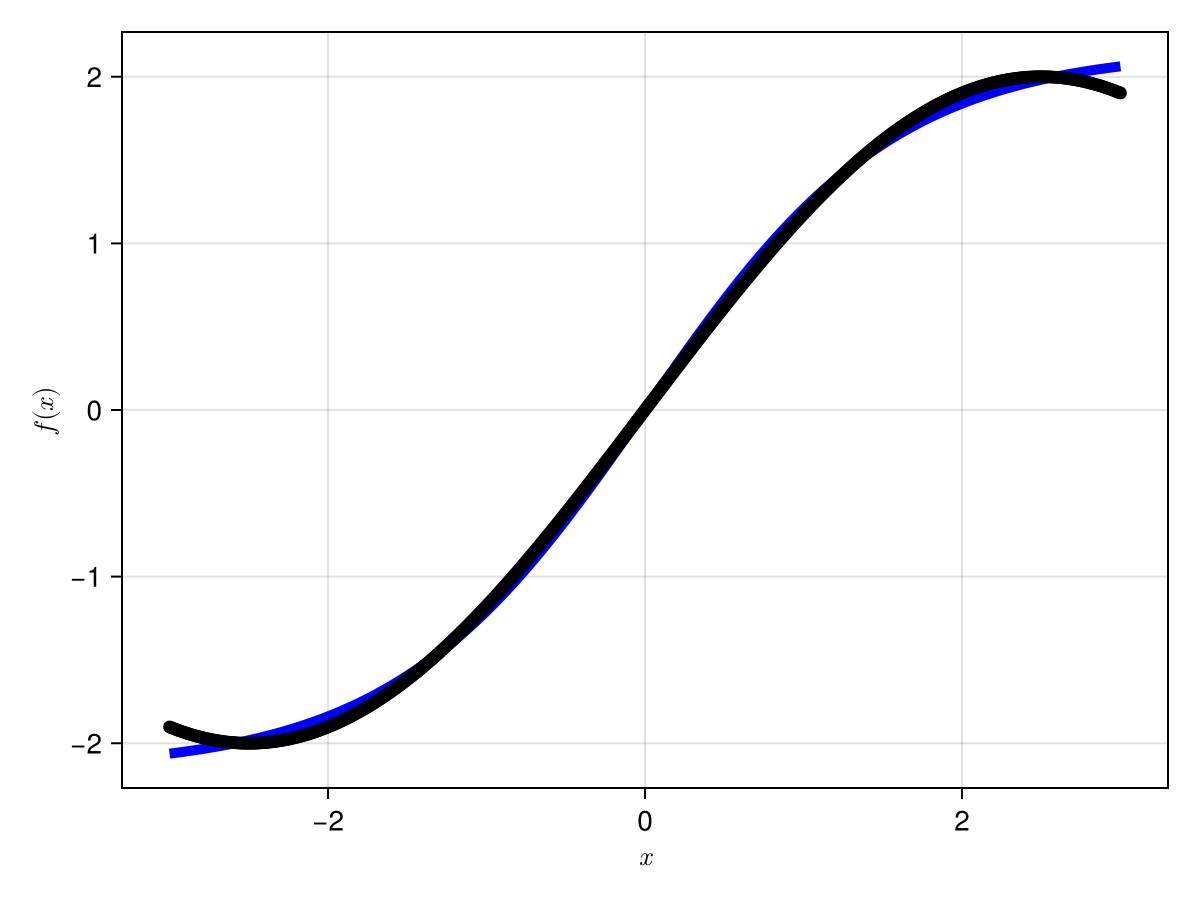

In [25]:
y_prediction,_=model03(xgrid',parameters03, layer_states03)


fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)")
lines!(ax,xgrid[:],y_prediction[:];color=:blue,label="prediction",linewidth=5)
scatter!(ax,xgrid[:],data03[:];color=:black,label="data")
fig

In [26]:
f03_loss(parameters03)

0.0011936305127456543

---

Now we will use the optimisation routines in Julia to train the Neural Network

In [27]:
callback = function (p, l)
    if length(loss_history) % 100 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction(loss_fn03, adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(parameters03),layer_states03)

# Initialize a vector to store loss values
loss_history = Float64[]
neural_network = Optimization.solve(optprob, OptimizationOptimisers.Adam(0.01); callback, maxiters = 1000)

parameters03=neural_network.u


Iteration: 1, Loss: 0.0011936305127456543
Iteration: 101, Loss: 0.0011936305071361944
Iteration: 201, Loss: 0.001193628776664015
Iteration: 301, Loss: 0.0011936287766511797
Iteration: 401, Loss: 0.0011936287766759505
Iteration: 501, Loss: 0.001193628776669221
Iteration: 601, Loss: 0.0011936287766354029
Iteration: 701, Loss: 0.001193628776691832
Iteration: 801, Loss: 0.0011936287768013175
Iteration: 901, Loss: 0.0011936287767116392
Iteration: 1000, Loss: 0.0011936287766241454


ComponentVector{Float32}(layer_1 = (weight = Float32[0.6321452;;], bias = Float32[6.088589f-17]), layer_2 = (weight = Float32[2.157455;;], bias = Float32[6.600071f-17]))

Calculate the loss for the current set of parameters

In [28]:
loss_fn03(parameters03, layer_states03)

0.0011936287766241454

Plot to see if the prediction from the new model matches the data

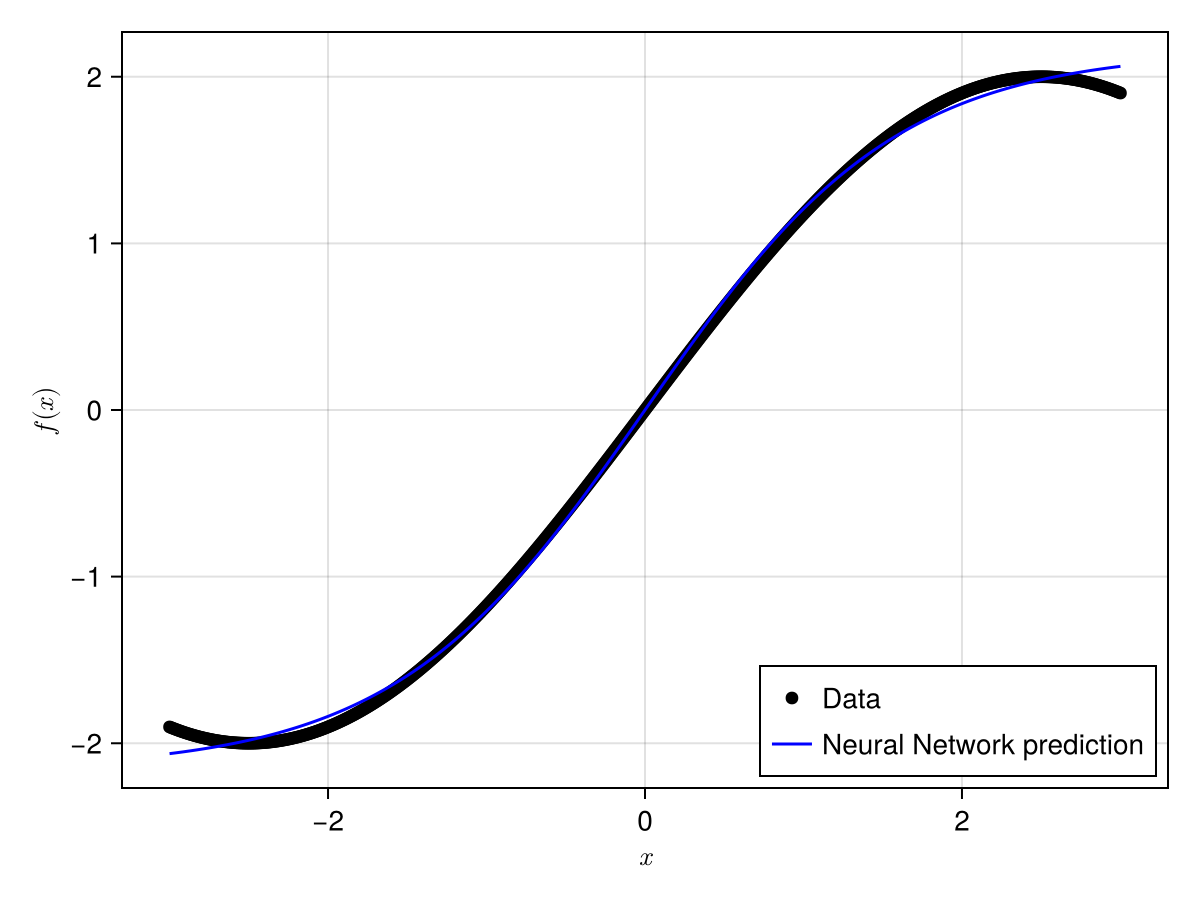

In [29]:
y_prediction,_=model03(reshape(xgrid,(1,N_SAMPLES)),parameters03, layer_states03)

fig = Figure()
ax = CairoMakie.Axis(fig[1, 1], xlabel = L"x", ylabel = L"f(x)")
scatter!(ax,xgrid,data03;color=:black,label="Data")
lines!(ax,xgrid,y_prediction[:];color=:blue,label="Neural Network prediction")
axislegend(ax,  position = :rb,orientation = :vertical)
fig

---

**Class Demo 02:** Construct a single input single output Neural Network using Lux in Julia to fit the data "Data05.csv"

---